# Day 4 — Dataset splitting validation

This notebook audits the saved train/validation/test partitions. Complete record groups are kept together. `patient_group` contains record-derived pseudonyms except the documented shared group for records 201/202; this is not a complete verified patient identity map. No model is trained and no class balancing is applied.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'configs/preprocessing/mitbih_split_v1.json').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.preprocessing.splitting import validate_saved_splits
split_dir = ROOT / 'data/splits/mitbih_v1'
label_config = ROOT / 'configs/preprocessing/mitbih_v1.json'
metadata = json.loads((split_dir / 'split_metadata.json').read_text(encoding='utf-8'))
checks = validate_saved_splits(split_dir, label_config)
print('Seed:', metadata['random_seed'], '| total records:', metadata['total_records'], '| record groups:', metadata['total_groups'], '| segments:', metadata['total_segments'])

Seed: 42 | total records: 48 | record groups: 47 | segments: 109460


## Partition sizes and proportions
Record and group counts use the record-group allocation; segment proportions can differ because record annotation counts vary.

In [2]:
rows = []
for name, info in metadata['splits'].items():
    rows.append({'split': name, 'groups': info['group_count'], 'records': info['record_count'], 'segments': info['segment_count'], 'record %': 100*info['record_proportion'], 'segment %': 100*info['segment_proportion']})
pd.DataFrame(rows).set_index('split').round(2)

,groups,records,segments,record %,segment %
split,,,,,
test,7,7,15559,14.58,14.21
train,33,33,77550,68.75,70.85
validation,7,8,16351,16.67,14.94


## Leakage and data integrity checks
The module reopens every saved shard, verifies expected arrays and metadata fields, validates labels and shapes, checks finite signal values, checks duplicate provenance and hashes segment content plus label across partitions, and compares record-group membership across splits.

In [3]:
overlap_rows = []
for pair, values in metadata['overlap_checks'].items():
    overlap_rows.append({'comparison': pair, 'record overlap': values['record_ids'], 'group overlap': values['group_ids']})
display(pd.DataFrame(overlap_rows).set_index('comparison'))
print('Validation flags:', metadata['validation'])
assert all(not x['record_ids'] and not x['group_ids'] for x in metadata['overlap_checks'].values())
assert all(not checks['record_sets'][a] & checks['record_sets'][b] and not checks['group_sets'][a] & checks['group_sets'][b] for a,b in [('train','validation'),('train','test'),('validation','test')])

,record overlap,group overlap
comparison,,
train_vs_test,[],[]
train_vs_validation,[],[]
validation_vs_test,[],[]


Validation flags: {'duplicate_content_across_splits': False, 'duplicate_provenance_across_splits': False, 'expected_dimensions': [216, 2], 'finite_values': True, 'group_overlap': False, 'metadata_fields': ['annotation_samples', 'channel_names', 'ends', 'labels', 'patient_groups', 'record_ids', 'sampling_frequency_hz', 'segments', 'source_symbols', 'starts'], 'record_overlap': False, 'same_seed_reproducible': True, 'valid_labels': True}


## Class distributions
Counts are reported for every original Day 2 source label. A zero is retained for absent classes; no classes or records are removed to improve the distribution.

,test,train,validation
/,2078,3407,1542
A,50,2418,78
E,0,106,0
F,13,782,7
J,0,80,3
L,2001,3948,2123
N,10197,53489,11342
Q,4,29,0
R,0,7255,0
S,0,2,0


Absent classes by split: {'test': ['E', 'J', 'R', 'S', 'e', 'f', 'j'], 'train': [], 'validation': ['E', 'Q', 'R', 'S', 'e']}


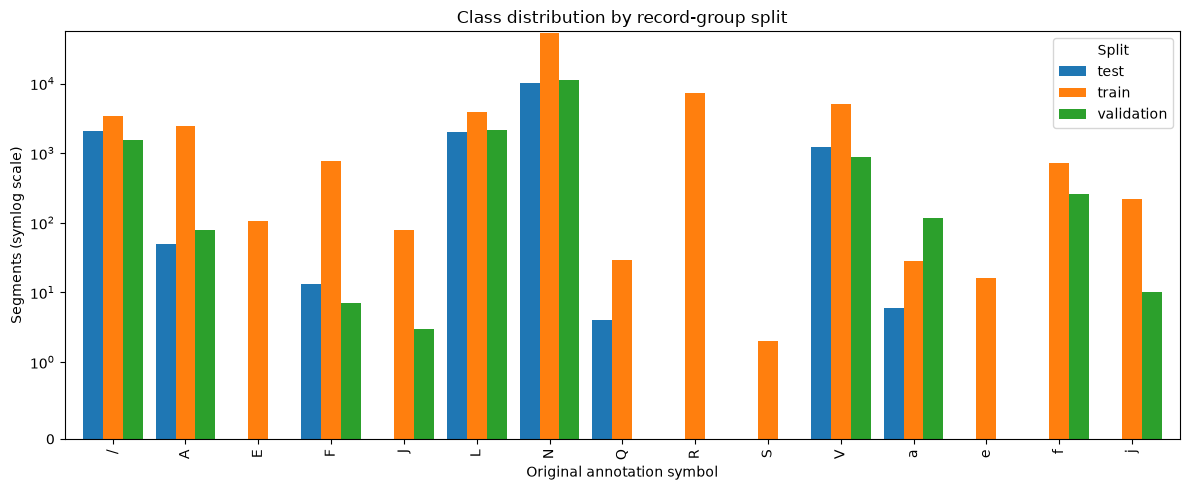

In [4]:
classes = metadata['valid_labels']
distribution = pd.DataFrame({split: {label: info['class_distribution'].get(label, 0) for label in classes} for split, info in metadata['splits'].items()}).fillna(0).astype(int)
display(distribution)
absent = {split: [label for label in classes if distribution.loc[label, split] == 0] for split in distribution.columns}
print('Absent classes by split:', absent)
fig, ax = plt.subplots(figsize=(12, 5))
distribution.plot(kind='bar', ax=ax, width=.82)
ax.set_yscale('symlog', linthresh=1); ax.set_ylabel('Segments (symlog scale)'); ax.set_xlabel('Original annotation symbol'); ax.set_title('Class distribution by record-group split'); ax.legend(title='Split')
fig.tight_layout(); fig.savefig(ROOT / 'results/figures/mitbih_split_class_distribution.png', dpi=160); plt.show()

## Interpretation limits
This is a seeded random group split, not a label-stratified split. Rare source labels may be absent or sparse in evaluation partitions. `201` and `202` are grouped because PhysioNet documents the same analog tape; the remaining group keys are record IDs and do not prove patient uniqueness. Review `docs/dataset_splits.md` before using these partitions for Day 5 model experiments.